# Data Cleaning
### Oasis Infobyte — Data Analytics Internship | Task 3

**Objective:** Identify and resolve data quality issues such as missing values,
duplicate records, inconsistent formatting, incorrect data types, and outliers
to produce a clean and reliable dataset for further analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Oasis_Task3_Messy_Sales_Dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Category,Product,Quantity,Unit_Price,Total_Amount,Payment_Method
0,ORD10001,2025-09-21,CUST1022,Vijay S,27.0,Male,Trichy,Electronics,Smartwatch,4,4984.11,19936.44,Net Banking
1,ORD10002,2026-04-17,CUST1210,Rahul K,42.0,Male,Coimbatore,Beauty,Hair Dryer,4,1510.34,6041.36,Net Banking
2,ORD10003,09/05/2026,CUST1113,Karthik R,22.0,Female,Thanjavur,Beauty,Skin Cream,3,638.97,1916.91,UPI
3,ORD10004,2026-01-14,CUST1176,Divya M,21.0,Female,Madurai,Sports,Sports Shoes,2,3016.79,6033.58,Net Banking
4,ORD10005,2025-04-27,CUST1125,Arun Kumar,44.0,Male,Salem,Beauty,Hair Dryer,4,1683.03,6732.12,Cash


## Initial Data Quality Inspection

Before cleaning the dataset, the data will be inspected for its structure,
missing values, duplicate records, inconsistent data types, and unusual values.


In [3]:
df.shape

(1015, 13)

In [4]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Category', 'Product', 'Quantity', 'Unit_Price',
       'Total_Amount', 'Payment_Method'],
      dtype='object')

In [5]:
df.dtypes

,0
Order_ID,object
Order_Date,object
Customer_ID,object
Customer_Name,object
Age,float64
Gender,object
City,object
Category,object
Product,object
Quantity,int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        1015 non-null   object 
 1   Order_Date      1015 non-null   object 
 2   Customer_ID     1015 non-null   object 
 3   Customer_Name   1000 non-null   object 
 4   Age             996 non-null    float64
 5   Gender          1015 non-null   object 
 6   City            1004 non-null   object 
 7   Category        1015 non-null   object 
 8   Product         1015 non-null   object 
 9   Quantity        1015 non-null   int64  
 10  Unit_Price      1015 non-null   object 
 11  Total_Amount    1015 non-null   float64
 12  Payment_Method  1005 non-null   object 
dtypes: float64(2), int64(1), object(10)
memory usage: 103.2+ KB


In [7]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,15
Age,19
Gender,0
City,11
Category,0
Product,0
Quantity,0


In [8]:
df.duplicated().sum()

np.int64(15)

In [9]:
df.describe(include='all')

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Category,Product,Quantity,Unit_Price,Total_Amount,Payment_Method
count,1015,1015,1015,1000,996.000000,1015,1004,1015,1015,1015.000000,1015,1015.000000,1005
unique,1000,506,247,10,NaN,3,8,5,20,NaN,998,NaN,6
top,ORD10812,2025-12-23,CUST1241,Rahul K,NaN,Male,Trichy,Sports,Sports Shoes,NaN,884.48,NaN,Net Banking
freq,2,10,11,124,NaN,504,174,232,66,NaN,2,NaN,250
mean,NaN,NaN,NaN,NaN,41.926707,NaN,NaN,NaN,NaN,3.220690,NaN,15063.132542,NaN
std,NaN,NaN,NaN,NaN,14.513402,NaN,NaN,NaN,NaN,3.849814,NaN,35089.096631,NaN
min,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,1.000000,NaN,299.040000,NaN
25%,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,2.000000,NaN,2464.330000,NaN
50%,NaN,NaN,NaN,NaN,42.000000,NaN,NaN,NaN,NaN,3.000000,NaN,4939.110000,NaN
75%,NaN,NaN,NaN,NaN,53.000000,NaN,NaN,NaN,NaN,4.000000,NaN,10047.290000,NaN


## Data Cleaning

A copy of the original dataset is created so that the original data remains
unchanged and the results before and after cleaning can be compared.

In [10]:
clean_df = df.copy()

In [11]:
print("Duplicate rows before cleaning:", clean_df.duplicated().sum())

Duplicate rows before cleaning: 15


In [12]:
clean_df = clean_df.drop_duplicates()

print("Duplicate rows after cleaning:", clean_df.duplicated().sum())
print("Rows remaining:", len(clean_df))

Duplicate rows after cleaning: 0
Rows remaining: 1000


### Duplicate Handling — Observation

- Exact duplicate transaction records were identified and removed.
- Duplicate rows can distort calculations and give repeated transactions more weight than they should have.
- Removing duplicates ensures that each transaction record is represented only once.

In [13]:
clean_df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,15
Age,18
Gender,0
City,11
Category,0
Product,0
Quantity,0


In [14]:
clean_df['Customer_Name'] = clean_df['Customer_Name'].fillna('Unknown')

clean_df['City'] = clean_df['City'].fillna('Unknown')

clean_df['Payment_Method'] = clean_df['Payment_Method'].fillna('Unknown')

clean_df['Age'] = clean_df['Age'].fillna(clean_df['Age'].median())

In [15]:
clean_df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
Category,0
Product,0
Quantity,0


### Missing Value Handling — Observation

- Missing Customer_Name, City, and Payment_Method values were replaced with "Unknown" because these are categorical/text fields.
- Missing Age values were replaced with the median age.
- Median was chosen for Age because it is less sensitive to extreme values than the mean.
- This approach preserves usable transaction records instead of unnecessarily deleting them.

In [16]:
print(clean_df['Gender'].value_counts())
print()
print(clean_df['City'].value_counts())
print()
print(clean_df['Payment_Method'].value_counts())

Gender
Female    497
Male      493
male       10
Name: count, dtype: int64

City
Chennai       172
Trichy        171
Coimbatore    163
Madurai       161
Thanjavur     154
Salem         148
Unknown        11
 chennai       10
COIMBATORE     10
Name: count, dtype: int64

Payment_Method
Net Banking    247
Card           243
Cash           242
UPI            238
 card           10
upi             10
Unknown         10
Name: count, dtype: int64


In [17]:
clean_df['Gender'] = clean_df['Gender'].str.strip().str.title()

clean_df['City'] = clean_df['City'].str.strip().str.title()

clean_df['Payment_Method'] = clean_df['Payment_Method'].str.strip().str.title()

In [18]:
print(clean_df['Gender'].value_counts())
print()
print(clean_df['City'].value_counts())
print()
print(clean_df['Payment_Method'].value_counts())

Gender
Male      503
Female    497
Name: count, dtype: int64

City
Chennai       182
Coimbatore    173
Trichy        171
Madurai       161
Thanjavur     154
Salem         148
Unknown        11
Name: count, dtype: int64

Payment_Method
Card           253
Upi            248
Net Banking    247
Cash           242
Unknown         10
Name: count, dtype: int64


### Formatting Standardization — Observation

- Extra spaces were removed from categorical text values.
- Gender, City, and Payment_Method values were standardized to consistent capitalization.
- This prevents identical categories from being treated as different groups because of formatting differences.

In [25]:
clean_df['Unit_Price'].head()

,Unit_Price
0,4984.11
1,1510.34
2,638.97
3,3016.79
4,1683.03


In [19]:
clean_df['Unit_Price'].dtype

dtype('O')

In [26]:
clean_df['Unit_Price'] = (
    clean_df['Unit_Price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
)

clean_df['Unit_Price'] = pd.to_numeric(
    clean_df['Unit_Price'],
    errors='coerce'
)

In [27]:
clean_df['Unit_Price'].dtype

dtype('float64')

In [28]:
clean_df['Order_Date'] = pd.to_datetime(
    clean_df['Order_Date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [29]:
print(clean_df['Order_Date'].dtype)
print("Invalid dates:", clean_df['Order_Date'].isnull().sum())

datetime64[ns]
Invalid dates: 0


In [30]:
clean_df.dtypes

,0
Order_ID,object
Order_Date,datetime64[ns]
Customer_ID,object
Customer_Name,object
Age,float64
Gender,object
City,object
Category,object
Product,object
Quantity,int64


### Data Type Correction — Observation

- Unit_Price was cleaned by removing currency symbols and commas and was converted to a numeric data type.
- Order_Date contained multiple date formats and was standardized to datetime format.
- Correct data types are important for numerical calculations, date analysis, sorting, and filtering.

## Outlier Detection and Treatment

Outliers are unusually high or low values that may affect statistical analysis.
The Interquartile Range (IQR) method is used to identify potential outliers in
the numerical columns.

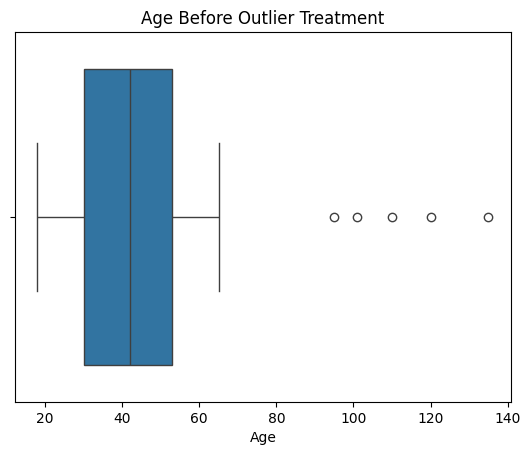

In [31]:
sns.boxplot(x=clean_df['Age'])
plt.title('Age Before Outlier Treatment')
plt.show()

In [32]:
Q1 = clean_df['Age'].quantile(0.25)
Q3 = clean_df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -4.5
Upper Bound: 87.5


In [33]:
age_outliers = clean_df[
    (clean_df['Age'] < lower_bound) |
    (clean_df['Age'] > upper_bound)
]

print("Age outliers:", len(age_outliers))

age_outliers[['Order_ID', 'Age']]

Age outliers: 5


,Order_ID,Age
199,ORD10200,101.0
288,ORD10289,110.0
358,ORD10359,135.0
810,ORD10811,120.0
911,ORD10912,95.0


In [34]:
median_age = clean_df['Age'].median()

clean_df.loc[
    (clean_df['Age'] < lower_bound) |
    (clean_df['Age'] > upper_bound),
    'Age'
] = median_age

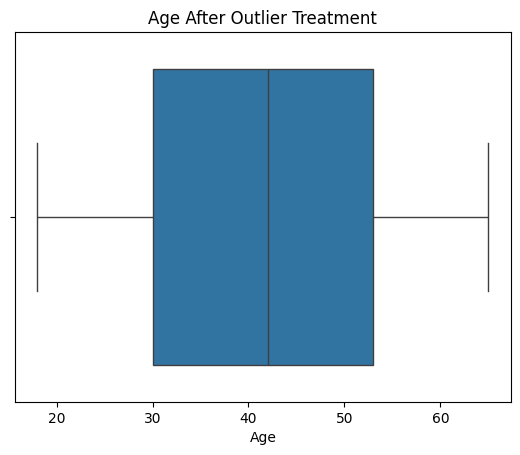

In [35]:
sns.boxplot(x=clean_df['Age'])
plt.title('Age After Outlier Treatment')
plt.show()

### Age Outlier Observation

- The IQR method identified unusually high Age values.
- Extreme ages were considered likely data-entry errors.
- Instead of deleting the complete transaction records, these values were
  replaced with the median age.
- Median replacement reduces the influence of invalid extreme values while
  preserving the remaining transaction information.

In [36]:
Q1_qty = clean_df['Quantity'].quantile(0.25)
Q3_qty = clean_df['Quantity'].quantile(0.75)

IQR_qty = Q3_qty - Q1_qty

lower_qty = Q1_qty - 1.5 * IQR_qty
upper_qty = Q3_qty + 1.5 * IQR_qty

quantity_outliers = clean_df[
    (clean_df['Quantity'] < lower_qty) |
    (clean_df['Quantity'] > upper_qty)
]

print("Quantity Lower Bound:", lower_qty)
print("Quantity Upper Bound:", upper_qty)
print("Quantity outliers:", len(quantity_outliers))

quantity_outliers[['Order_ID', 'Product', 'Quantity', 'Total_Amount']]

Quantity Lower Bound: -1.0
Quantity Upper Bound: 7.0
Quantity outliers: 5


,Order_ID,Product,Quantity,Total_Amount
719,ORD10720,T-Shirt,60,2373.90
726,ORD10727,Sports Shoes,75,8365.11
728,ORD10729,Mixer,42,11970.60
762,ORD10763,Cricket Bat,35,11046.00
801,ORD10802,Laptop,50,204021.80


In [37]:
clean_df.loc[
    clean_df['Quantity'] > upper_qty,
    'Quantity'
] = int(upper_qty)

print("Maximum Quantity after treatment:",
      clean_df['Quantity'].max())

Maximum Quantity after treatment: 7


In [38]:
clean_df['Total_Amount'] = (
    clean_df['Quantity'] * clean_df['Unit_Price']
).round(2)

In [39]:
clean_df[['Quantity', 'Unit_Price', 'Total_Amount']].describe()

,Quantity,Unit_Price,Total_Amount
count,1000.000000,1000.00000,1000.000000
mean,3.004000,5263.72878,15294.858740
std,1.397117,11436.25932,36416.550228
min,1.000000,299.04000,299.040000
25%,2.000000,886.75750,2464.920000
50%,3.000000,1888.41000,4912.910000
75%,4.000000,3068.03750,10072.410000
max,7.000000,59602.08000,357038.150000


### Quantity Outlier Treatment — Observation

- The IQR method identified 5 unusually large Quantity values.
- These values were capped at the IQR upper bound rather than removing the entire transaction.
- Capping reduces the influence of extreme values while preserving the transaction records.
- Total_Amount was recalculated after Quantity treatment to maintain consistency between Quantity, Unit_Price, and Total_Amount.

### Z-Score Outlier Detection

In addition to the IQR method, the Z-score method can be used to identify
values that are unusually far from the mean. A common threshold is an
absolute Z-score greater than 3.

In [41]:
clean_df['Amount_ZScore'] = (
    clean_df['Total_Amount'] - clean_df['Total_Amount'].mean()
) / clean_df['Total_Amount'].std()

z_outliers = clean_df[
    clean_df['Amount_ZScore'].abs() > 3
]

print("Z-score outliers:", len(z_outliers))

z_outliers[
    ['Order_ID', 'Product', 'Quantity',
     'Unit_Price', 'Total_Amount', 'Amount_ZScore']
].head(10)

Z-score outliers: 29


,Order_ID,Product,Quantity,Unit_Price,Total_Amount,Amount_ZScore
21,ORD10022,Laptop,4,45813.09,183252.36,4.612120
64,ORD10065,Laptop,4,55397.06,221588.24,5.664825
80,ORD10081,Laptop,5,53377.58,266887.90,6.908755
110,ORD10111,Laptop,3,47126.46,141379.38,3.462286
150,ORD10151,Laptop,3,44904.70,134714.10,3.279257
193,ORD10194,Laptop,5,44743.48,223717.40,5.723292
268,ORD10269,Laptop,5,48147.34,240736.70,6.190642
321,ORD10322,Laptop,3,44487.63,133462.89,3.244899
387,ORD10388,Laptop,4,48298.58,193194.32,4.885127
413,ORD10414,Laptop,5,52080.39,260401.95,6.730651


### Z-Score Observation

- Z-scores were calculated for Total_Amount using a threshold of |Z| > 3.
- Transactions exceeding this threshold were identified as potential outliers.
- These records were not automatically removed because high-value purchases
  may represent legitimate transactions rather than data-entry errors.
- Outliers should be evaluated using business context before removal.

In [42]:
clean_df = clean_df.drop(columns=['Amount_ZScore'])

In [43]:
print("Final Shape:", clean_df.shape)
print("\nMissing Values:")
print(clean_df.isnull().sum())

print("\nDuplicate Rows:", clean_df.duplicated().sum())

print("\nData Types:")
print(clean_df.dtypes)

Final Shape: (1000, 13)

Missing Values:
Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age               0
Gender            0
City              0
Category          0
Product           0
Quantity          0
Unit_Price        0
Total_Amount      0
Payment_Method    0
dtype: int64

Duplicate Rows: 0

Data Types:
Order_ID                  object
Order_Date        datetime64[ns]
Customer_ID               object
Customer_Name             object
Age                      float64
Gender                    object
City                      object
Category                  object
Product                   object
Quantity                   int64
Unit_Price               float64
Total_Amount             float64
Payment_Method            object
dtype: object


In [44]:
clean_df.describe()

,Order_Date,Age,Quantity,Unit_Price,Total_Amount
count,1000,1000.000000,1000.000000,1000.00000,1000.000000
mean,2025-10-19 10:23:31.200000,41.547000,3.004000,5263.72878,15294.858740
min,2025-01-01 00:00:00,18.000000,1.000000,299.04000,299.040000
25%,2025-05-17 00:00:00,30.000000,2.000000,886.75750,2464.920000
50%,2025-10-20 12:00:00,42.000000,3.000000,1888.41000,4912.910000
75%,2026-03-21 00:00:00,53.000000,4.000000,3068.03750,10072.410000
max,2026-08-23 00:00:00,65.000000,7.000000,59602.08000,357038.150000
std,NaN,13.471573,1.397117,11436.25932,36416.550228


## Before vs After Cleaning Summary

In [45]:
summary = pd.DataFrame({
    'Metric': [
        'Number of Rows',
        'Missing Values',
        'Duplicate Rows',
        'Age Maximum',
        'Quantity Maximum'
    ],
    'Before Cleaning': [
        len(df),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df['Age'].max(),
        df['Quantity'].max()
    ],
    'After Cleaning': [
        len(clean_df),
        clean_df.isnull().sum().sum(),
        clean_df.duplicated().sum(),
        clean_df['Age'].max(),
        clean_df['Quantity'].max()
    ]
})

summary

,Metric,Before Cleaning,After Cleaning
0,Number of Rows,1015.0,1000.0
1,Missing Values,55.0,0.0
2,Duplicate Rows,15.0,0.0
3,Age Maximum,135.0,65.0
4,Quantity Maximum,75.0,7.0


### Cleaning Summary

The cleaning process improved the overall quality and consistency of the dataset.

- Duplicate records were removed.
- Missing values were handled using appropriate strategies.
- Inconsistent categorical values were standardized.
- Mixed date formats were converted into a consistent datetime format.
- Unit_Price was converted from mixed text/numeric values into a numeric data type.
- Invalid Age outliers were replaced using the median.
- Extreme Quantity values were capped using the IQR upper bound.
- Total_Amount was recalculated to maintain consistency after Quantity treatment.
- Potential high-value transaction outliers were also examined using Z-scores.

In [46]:
clean_df.to_csv(
    'Oasis_Task3_Cleaned_Sales_Dataset.csv',
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [47]:
pd.read_csv('Oasis_Task3_Cleaned_Sales_Dataset.csv').head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Category,Product,Quantity,Unit_Price,Total_Amount,Payment_Method
0,ORD10001,2025-09-21,CUST1022,Vijay S,27.0,Male,Trichy,Electronics,Smartwatch,4,4984.11,19936.44,Net Banking
1,ORD10002,2026-04-17,CUST1210,Rahul K,42.0,Male,Coimbatore,Beauty,Hair Dryer,4,1510.34,6041.36,Net Banking
2,ORD10003,2026-05-09,CUST1113,Karthik R,22.0,Female,Thanjavur,Beauty,Skin Cream,3,638.97,1916.91,Upi
3,ORD10004,2026-01-14,CUST1176,Divya M,21.0,Female,Madurai,Sports,Sports Shoes,2,3016.79,6033.58,Net Banking
4,ORD10005,2025-04-27,CUST1125,Arun Kumar,44.0,Male,Salem,Beauty,Hair Dryer,4,1683.03,6732.12,Cash


## Conclusion

The sales dataset was successfully cleaned and prepared for further analysis.

The cleaning process addressed missing values, duplicate records, inconsistent
text formatting, mixed date formats, incorrect data types, and numerical
outliers. The IQR method was used to detect and treat abnormal Age and Quantity
values, while Z-score analysis was used to identify potential extreme
transaction amounts.

Rather than automatically removing every statistical outlier, business context
was considered before treatment. This helped preserve potentially valid
high-value transactions while correcting values that were likely data-quality
problems.

The final dataset contains 1,000 cleaned transaction records with no missing
values or duplicate rows and is ready for reliable analysis and reporting.